In [1]:
import os
import re
import cv2
import numpy as np
import pandas as pd
from pathlib import Path
from scipy.stats import skew, kurtosis, entropy
from skimage.feature import graycomatrix, graycoprops, local_binary_pattern
from skimage.measure import label, regionprops
import SimpleITK as sitk
from radiomics import featureextractor

In [2]:
file_path=r"C:\Users\HP PC\Downloads\archive (6)\Dataset_BUSI_with_GT"
os.listdir(file_path)

['benign', 'malignant', 'normal']

###  HELPERS

In [3]:
def load_gray_image(path):
    img = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError(f"Could not read image: {path}")
    return img

def normalize_image(img):
    # consistent normalization
    img = cv2.equalizeHist(img)
    return img

def collect_mask_paths(image_path):
    """
    Finds:
    benign (1)_mask.png
    benign (1)_mask_1.png
    benign (1)_mask_2.png
    etc.
    """
    image_path = Path(image_path)
    stem = image_path.stem
    parent = image_path.parent
    pattern = re.compile(rf"^{re.escape(stem)}_mask(?:_\d+)?\.png$")
    mask_paths = sorted([p for p in parent.iterdir() if pattern.match(p.name)])
    return mask_paths

def merge_masks(mask_paths, shape=None):
    if not mask_paths:
        if shape is not None:
            return np.zeros(shape, dtype=np.uint8)
        return None

    merged = None
    for mp in mask_paths:
        mask = cv2.imread(str(mp), cv2.IMREAD_GRAYSCALE)
        if mask is None:
            continue
        mask = (mask > 0).astype(np.uint8)
        if merged is None:
            merged = mask
        else:
            merged = np.maximum(merged, mask)

    if merged is None and shape is not None:
        return np.zeros(shape, dtype=np.uint8)

    return merged


###  Let Us See the Images

In [20]:
import os
import random
from pathlib import Path
import cv2
import matplotlib.pyplot as plt

# =========================
# DATASET PATH
# =========================
file_path = r"C:\Users\HP PC\Downloads\archive (6)\Dataset_BUSI_with_GT"

# =========================
# HELPER: GET ONLY REAL IMAGES
# =========================
def get_class_images(class_dir):
    class_dir = Path(class_dir)
    images = []
    for f in class_dir.glob("*.png"):
        if "_mask" not in f.stem:
            images.append(str(f))
    return sorted(images)

# =========================
# LOAD FILES
# =========================
benign_images = get_class_images(os.path.join(file_path, "benign"))
malignant_images = get_class_images(os.path.join(file_path, "malignant"))
normal_images = get_class_images(os.path.join(file_path, "normal"))

print("Benign images:", len(benign_images))
print("Malignant images:", len(malignant_images))
print("Normal images:", len(normal_images))

Benign images: 437
Malignant images: 210
Normal images: 133


### Let us view the Class Distribution in a bar chart

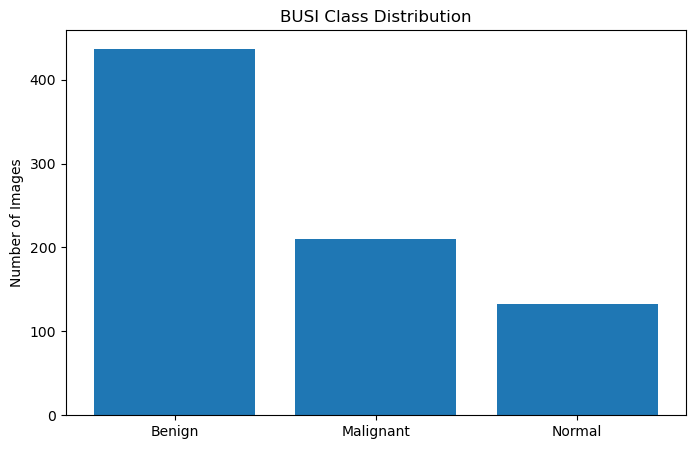

In [24]:
classes = ["Benign", "Malignant", "Normal"]
counts = [len(benign_images), len(malignant_images), len(normal_images)]

plt.figure(figsize=(8, 5))
plt.bar(classes, counts)
plt.title("BUSI Class Distribution")
plt.ylabel("Number of Images")
plt.show()

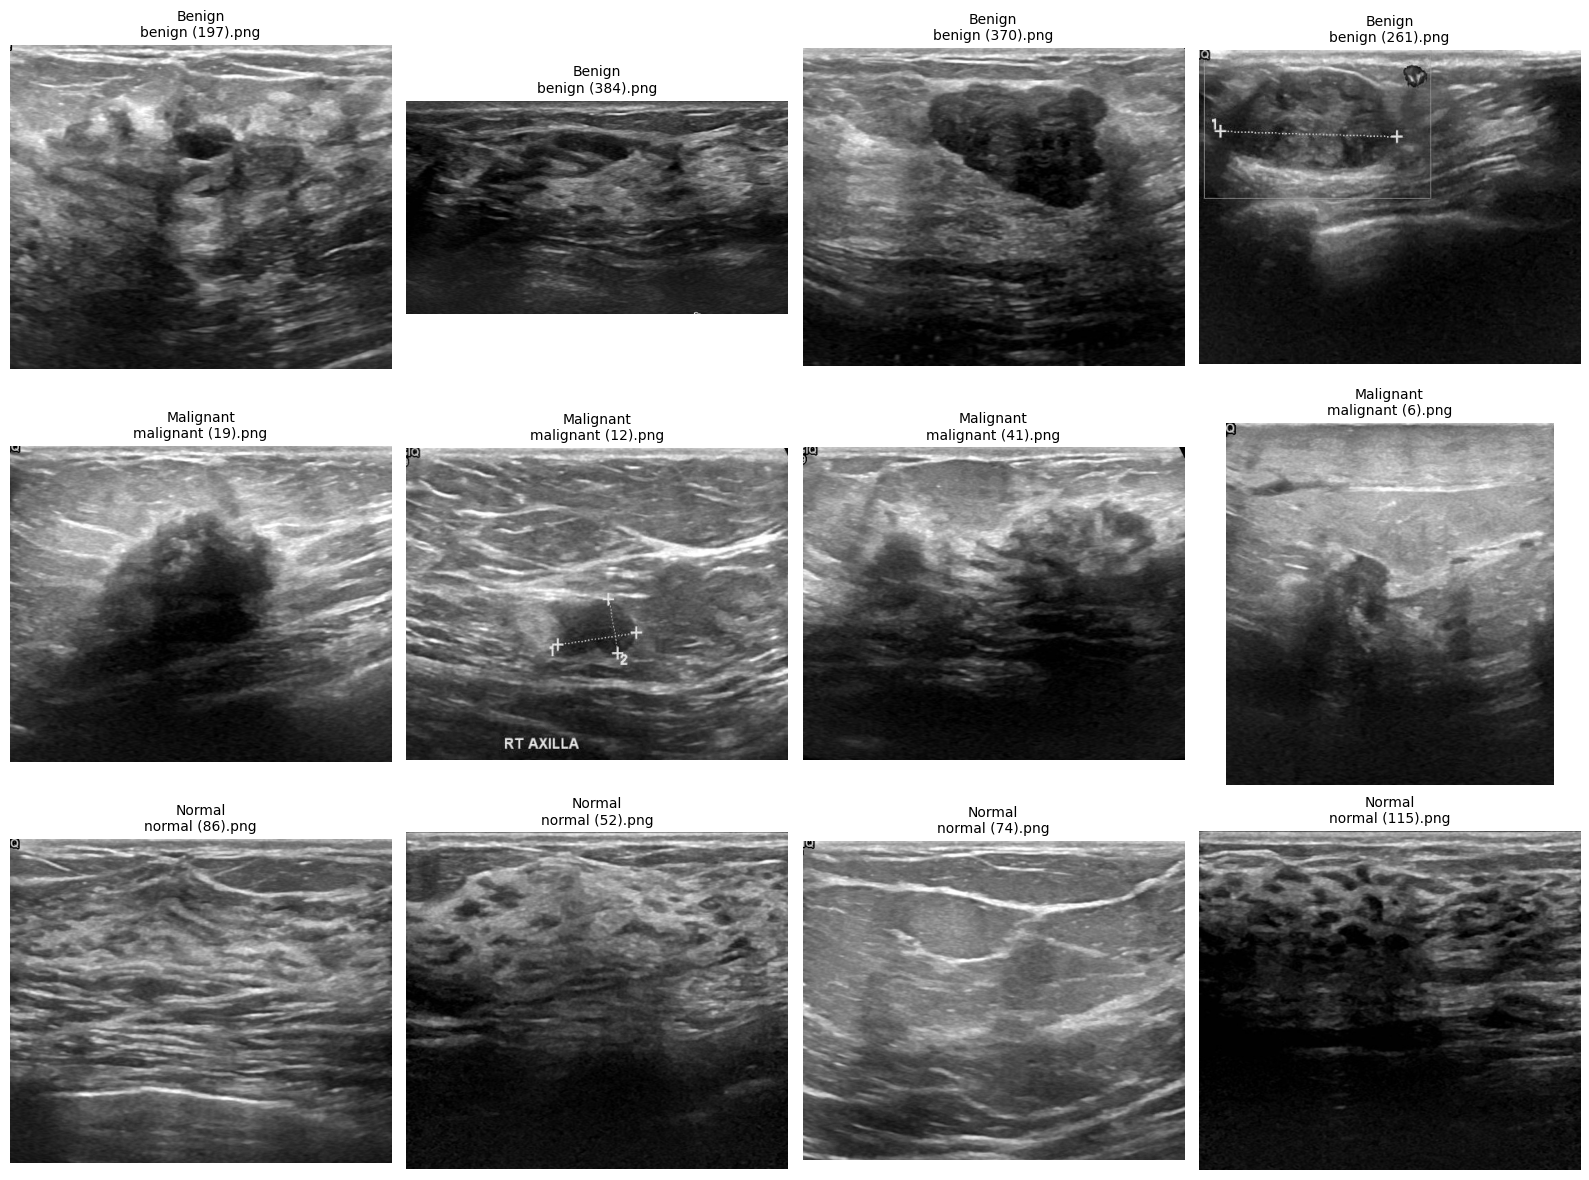

In [21]:
def show_all_classes_side_by_side(benign_images, malignant_images, normal_images, n=4):
    benign_sample = random.sample(benign_images, min(n, len(benign_images)))
    malignant_sample = random.sample(malignant_images, min(n, len(malignant_images)))
    normal_sample = random.sample(normal_images, min(n, len(normal_images)))

    all_samples = [
        ("Benign", benign_sample),
        ("Malignant", malignant_sample),
        ("Normal", normal_sample)
    ]

    plt.figure(figsize=(16, 12))

    plot_index = 1
    for row_idx, (class_name, sample_list) in enumerate(all_samples):
        for col_idx, img_path in enumerate(sample_list):
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

            plt.subplot(3, n, plot_index)
            plt.imshow(img, cmap="gray")
            plt.title(f"{class_name}\n{Path(img_path).name}", fontsize=10)
            plt.axis("off")
            plot_index += 1

    plt.tight_layout()
    plt.show()

show_all_classes_side_by_side(benign_images, malignant_images, normal_images, n=4)

###  Let us see IMAGE + MASK For BENIGN and MALIGNANT

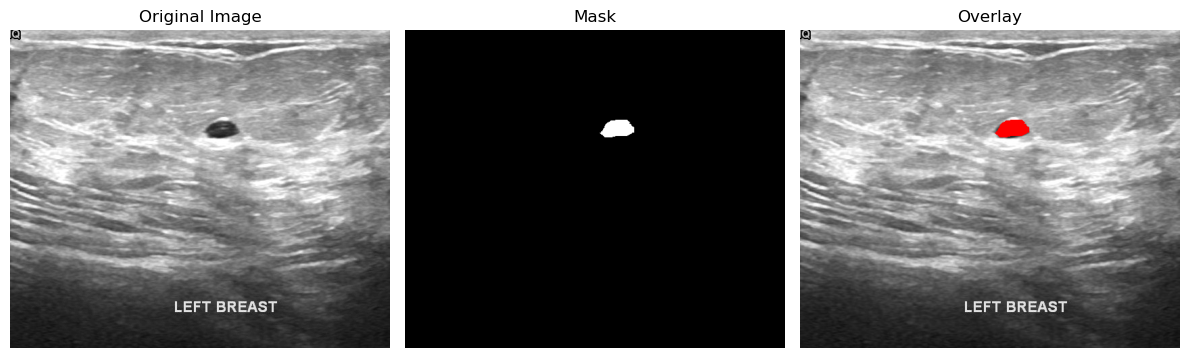

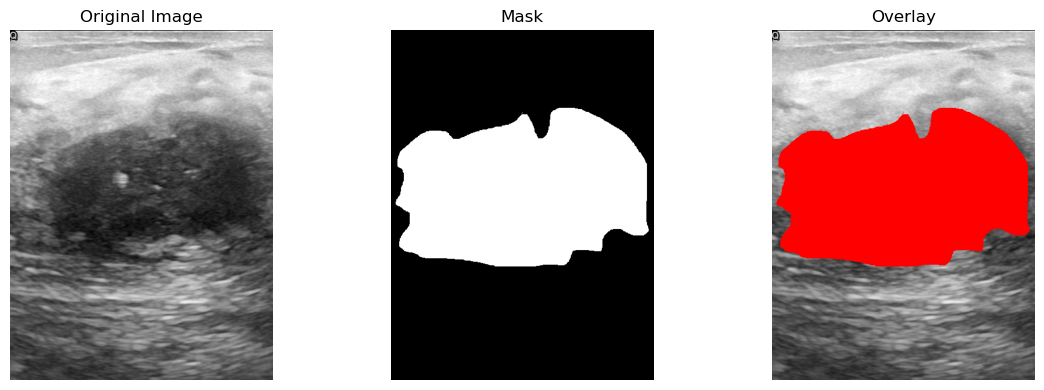

In [22]:
def get_mask_paths(image_path):
    image_path = Path(image_path)
    stem = image_path.stem
    parent = image_path.parent

    masks = []
    for f in parent.glob(f"{stem}_mask*.png"):
        masks.append(str(f))
    return sorted(masks)

def show_image_and_mask(image_path):
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    mask_paths = get_mask_paths(image_path)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(image, cmap="gray")
    plt.title("Original Image")
    plt.axis("off")

    if len(mask_paths) > 0:
        merged_mask = None
        for mp in mask_paths:
            mask = cv2.imread(mp, cv2.IMREAD_GRAYSCALE)
            mask = (mask > 0).astype("uint8")
            if merged_mask is None:
                merged_mask = mask
            else:
                merged_mask = merged_mask | mask

        plt.subplot(1, 3, 2)
        plt.imshow(merged_mask, cmap="gray")
        plt.title("Mask")
        plt.axis("off")

        overlay = image.copy()
        overlay = cv2.cvtColor(overlay, cv2.COLOR_GRAY2RGB)
        overlay[merged_mask > 0] = [255, 0, 0]

        plt.subplot(1, 3, 3)
        plt.imshow(overlay)
        plt.title("Overlay")
        plt.axis("off")
    else:
        plt.subplot(1, 3, 2)
        plt.text(0.5, 0.5, "No mask found", ha="center", va="center")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

# Example:
show_image_and_mask(benign_images[0])
show_image_and_mask(malignant_images[0])

### GLOBAL IMAGE FEATURES

In [4]:
def extract_global_features(img):
    flat = img.flatten().astype(np.float32)

    # histogram entropy
    hist, _ = np.histogram(flat, bins=256, range=(0, 256), density=True)
    hist = hist + 1e-12

    # edge density
    edges = cv2.Canny(img, 50, 150)

    # GLCM
    glcm = graycomatrix(
        img,
        distances=[1],
        angles=[0],
        levels=256,
        symmetric=True,
        normed=True
    )

    features = {
        "img_mean": float(np.mean(flat)),
        "img_std": float(np.std(flat)),
        "img_min": float(np.min(flat)),
        "img_max": float(np.max(flat)),
        "img_median": float(np.median(flat)),
        "img_skewness": float(skew(flat)),
        "img_kurtosis": float(kurtosis(flat)),
        "img_entropy": float(entropy(hist)),
        "img_edge_density": float(np.mean(edges > 0)),
        "img_glcm_contrast": float(graycoprops(glcm, "contrast")[0, 0]),
        "img_glcm_dissimilarity": float(graycoprops(glcm, "dissimilarity")[0, 0]),
        "img_glcm_homogeneity": float(graycoprops(glcm, "homogeneity")[0, 0]),
        "img_glcm_energy": float(graycoprops(glcm, "energy")[0, 0]),
        "img_glcm_correlation": float(graycoprops(glcm, "correlation")[0, 0]),
        "img_glcm_asm": float(graycoprops(glcm, "ASM")[0, 0]),
    }

    # LBP histogram
    radius = 1
    n_points = 8 * radius
    lbp = local_binary_pattern(img, n_points, radius, method="uniform")
    lbp_hist, _ = np.histogram(
        lbp.ravel(),
        bins=np.arange(0, n_points + 3),
        range=(0, n_points + 2),
        density=True
    )

    for i, val in enumerate(lbp_hist):
        features[f"img_lbp_{i}"] = float(val)

    return features


###  ROI SHAPE FEATURES

In [5]:
def extract_roi_shape_features(mask):
    zero_features = {
        "roi_area": 0.0,
        "roi_perimeter": 0.0,
        "roi_circularity": 0.0,
        "roi_eccentricity": 0.0,
        "roi_solidity": 0.0,
        "roi_extent": 0.0,
        "roi_major_axis_length": 0.0,
        "roi_minor_axis_length": 0.0,
        "roi_aspect_ratio": 0.0,
    }

    if mask is None or np.sum(mask) == 0:
        return zero_features

    labeled = label(mask)
    props = regionprops(labeled)

    if len(props) == 0:
        return zero_features

    # use largest lesion only for morphology
    prop = max(props, key=lambda x: x.area)

    area = float(prop.area)
    perimeter = float(prop.perimeter) if prop.perimeter > 0 else 0.0
    circularity = (4 * np.pi * area / (perimeter ** 2)) if perimeter > 0 else 0.0

    major_axis = float(getattr(prop, "major_axis_length", 0.0))
    minor_axis = float(getattr(prop, "minor_axis_length", 0.0))
    aspect_ratio = (major_axis / minor_axis) if minor_axis > 0 else 0.0

    features = {
        "roi_area": area,
        "roi_perimeter": perimeter,
        "roi_circularity": float(circularity),
        "roi_eccentricity": float(getattr(prop, "eccentricity", 0.0)),
        "roi_solidity": float(getattr(prop, "solidity", 0.0)),
        "roi_extent": float(getattr(prop, "extent", 0.0)),
        "roi_major_axis_length": major_axis,
        "roi_minor_axis_length": minor_axis,
        "roi_aspect_ratio": float(aspect_ratio),
    }

    return features

### ROI INTENSITY FEATURES

In [6]:
def extract_roi_intensity_features(img, mask):
    zero_features = {
        "roi_mean": 0.0,
        "roi_std": 0.0,
        "roi_min": 0.0,
        "roi_max": 0.0,
        "roi_median": 0.0,
        "roi_skewness": 0.0,
        "roi_kurtosis": 0.0,
    }

    if mask is None or np.sum(mask) == 0:
        return zero_features

    pixels = img[mask > 0].astype(np.float32)

    if len(pixels) == 0:
        return zero_features

    features = {
        "roi_mean": float(np.mean(pixels)),
        "roi_std": float(np.std(pixels)),
        "roi_min": float(np.min(pixels)),
        "roi_max": float(np.max(pixels)),
        "roi_median": float(np.median(pixels)),
        "roi_skewness": float(skew(pixels)) if len(pixels) > 2 else 0.0,
        "roi_kurtosis": float(kurtosis(pixels)) if len(pixels) > 3 else 0.0,
    }

    return features


### RADIOMICS EXTRACTOR

In [7]:
def build_radiomics_extractor():
    extractor = featureextractor.RadiomicsFeatureExtractor()

    extractor.settings["binWidth"] = 25
    extractor.settings["force2D"] = True
    extractor.settings["force2Ddimension"] = 0
    extractor.settings["normalize"] = True
    extractor.settings["normalizeScale"] = 100

    extractor.enableImageTypeByName("Original")

    extractor.enableFeatureClassByName("firstorder")
    extractor.enableFeatureClassByName("shape2D")
    extractor.enableFeatureClassByName("glcm")
    extractor.enableFeatureClassByName("glrlm")
    extractor.enableFeatureClassByName("glszm")
    extractor.enableFeatureClassByName("gldm")
    extractor.enableFeatureClassByName("ngtdm")

    return extractor

def extract_roi_radiomics(img, mask, extractor, all_radiomics_keys=None):
    """
    For benign/malignant: extract real radiomics.
    For normal/no lesion: return zeros for known radiomics keys.
    """
    if mask is None or np.sum(mask) == 0:
        if all_radiomics_keys is None:
            return {}
        return {k: 0.0 for k in all_radiomics_keys}

    img_sitk = sitk.GetImageFromArray(img.astype(np.float32))
    mask_sitk = sitk.GetImageFromArray(mask.astype(np.uint8))

    result = extractor.execute(img_sitk, mask_sitk)

    features = {}
    for k, v in result.items():
        if k.startswith("original_"):
            try:
                features[k] = float(v)
            except Exception:
                pass

    return features


### DATASET INDEXING

In [8]:
def build_dataset_index(root_dir):
    root_dir = Path(root_dir)
    rows = []

    for class_name in ["benign", "malignant", "normal"]:
        class_dir = root_dir / class_name

        for img_path in sorted(class_dir.glob("*.png")):
            if "_mask" in img_path.stem:
                continue

            if class_name == "normal":
                mask_paths = []
            else:
                mask_paths = collect_mask_paths(img_path)

            rows.append({
                "image_path": str(img_path),
                "label": class_name,
                "mask_paths": [str(m) for m in mask_paths]
            })

    return rows


###  MAIN EXTRACTION

In [9]:
def extract_features_for_case(image_path, label_name, mask_paths, extractor, known_radiomics_keys=None):
    img = load_gray_image(image_path)
    img = normalize_image(img)

    if label_name == "normal":
        mask = np.zeros(img.shape, dtype=np.uint8)
        has_lesion = 0
    else:
        mask = merge_masks(mask_paths, shape=img.shape)
        has_lesion = 1 if mask is not None and np.sum(mask) > 0 else 0

    record = {
        "image_path": image_path,
        "label": label_name,
        "has_lesion": has_lesion
    }

    # global features for all classes
    record.update(extract_global_features(img))

    # ROI handcrafted features
    if label_name == "normal":
        record.update(extract_roi_shape_features(None))
        record.update(extract_roi_intensity_features(img, None))
    else:
        record.update(extract_roi_shape_features(mask))
        record.update(extract_roi_intensity_features(img, mask))

    # ROI radiomics
    if label_name == "normal":
        roi_rad = extract_roi_radiomics(img, None, extractor, all_radiomics_keys=known_radiomics_keys)
    else:
        roi_rad = extract_roi_radiomics(img, mask, extractor, all_radiomics_keys=known_radiomics_keys)

    record.update(roi_rad)

    return record

def main():
    os.makedirs("outputs", exist_ok=True)

    dataset_index = build_dataset_index(file_path)
    extractor = build_radiomics_extractor()

    # pass 1: gather radiomics keys from abnormal cases only
    radiomics_key_set = set()

    print("Pass 1: discovering radiomics feature names...")
    for row in dataset_index:
        if row["label"] == "normal":
            continue

        img = load_gray_image(row["image_path"])
        img = normalize_image(img)
        mask = merge_masks(row["mask_paths"], shape=img.shape)

        if mask is None or np.sum(mask) == 0:
            continue

        rad = extract_roi_radiomics(img, mask, extractor)
        radiomics_key_set.update(rad.keys())

    known_radiomics_keys = sorted(list(radiomics_key_set))
    print(f"Discovered {len(known_radiomics_keys)} radiomics features.")

    # pass 2: build full dataset
    print("Pass 2: extracting all features...")
    records = []
    for i, row in enumerate(dataset_index, start=1):
        rec = extract_features_for_case(
            image_path=row["image_path"],
            label_name=row["label"],
            mask_paths=row["mask_paths"],
            extractor=extractor,
            known_radiomics_keys=known_radiomics_keys
        )
        records.append(rec)

        if i % 50 == 0 or i == len(dataset_index):
            print(f"Processed {i}/{len(dataset_index)}")

    df = pd.DataFrame(records)
    df = df.fillna(0.0)

    output_csv = "outputs/busi_3class_features.csv"
    df.to_csv(output_csv, index=False)

    print(f"\nSaved extracted features to: {output_csv}")
    print("Dataset shape:", df.shape)
    print("Class counts:")
    print(df["label"].value_counts())

if __name__ == "__main__":
    main()

Shape features are only available 3D input (for 2D input, use shape2D). Found 2D input
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated


Pass 1: discovering radiomics feature names...


Shape features are only available 3D input (for 2D input, use shape2D). Found 2D input
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
Shape features are only available 3D input (for 2D input, use shape2D). Found 2D input
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
Shape features are only available 3D input (for 2D input, use shape2D). Found 2D input
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
Shape features are only available 3D input (for 2D input, use shape2D). Found 2D input
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
Shape features are only available 3D input (for 2D input, use shape2D). Found 2D input
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
Shape features are only available 3D input (for 2D input, use shape2D). Found 2D input
GLCM is 

Discovered 102 radiomics features.
Pass 2: extracting all features...


Shape features are only available 3D input (for 2D input, use shape2D). Found 2D input
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
Shape features are only available 3D input (for 2D input, use shape2D). Found 2D input
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
Shape features are only available 3D input (for 2D input, use shape2D). Found 2D input
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
Shape features are only available 3D input (for 2D input, use shape2D). Found 2D input
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
Shape features are only available 3D input (for 2D input, use shape2D). Found 2D input
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
Shape features are only available 3D input (for 2D input, use shape2D). Found 2D input
GLCM is 

...

Processed 550/780


Shape features are only available 3D input (for 2D input, use shape2D). Found 2D input
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
Shape features are only available 3D input (for 2D input, use shape2D). Found 2D input
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
Shape features are only available 3D input (for 2D input, use shape2D). Found 2D input
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
Shape features are only available 3D input (for 2D input, use shape2D). Found 2D input
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
Shape features are only available 3D input (for 2D input, use shape2D). Found 2D input
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
Shape features are only available 3D input (for 2D input, use shape2D). Found 2D input
GLCM is 

Processed 600/780


Shape features are only available 3D input (for 2D input, use shape2D). Found 2D input
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
Shape features are only available 3D input (for 2D input, use shape2D). Found 2D input
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
Shape features are only available 3D input (for 2D input, use shape2D). Found 2D input
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
Shape features are only available 3D input (for 2D input, use shape2D). Found 2D input
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
Shape features are only available 3D input (for 2D input, use shape2D). Found 2D input
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
Shape features are only available 3D input (for 2D input, use shape2D). Found 2D input
GLCM is 

Processed 650/780
Processed 700/780
Processed 750/780
Processed 780/780

Saved extracted features to: outputs/busi_3class_features.csv
Dataset shape: (780, 146)
Class counts:
label
benign       437
malignant    210
normal       133
Name: count, dtype: int64


### training code

In [10]:
import os
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score
)

In [11]:
from sklearn.metrics import confusion_matrix
import pandas as pd
import os
import joblib
import matplotlib.pyplot as plt
import seaborn as sns


Accuracy: 0.9487

Classification Report:

              precision    recall  f1-score   support

      benign       0.94      0.97      0.95        87
   malignant       0.93      0.88      0.90        42
      normal       1.00      1.00      1.00        27

    accuracy                           0.95       156
   macro avg       0.96      0.95      0.95       156
weighted avg       0.95      0.95      0.95       156


CONFUSION MATRIX (RAW NUMERIC)
[[84  3  0]
 [ 5 37  0]
 [ 0  0 27]]

CONFUSION MATRIX (LABELED TABLE)
                  Predicted_benign  Predicted_malignant  Predicted_normal
Actual_benign                   84                    3                 0
Actual_malignant                 5                   37                 0
Actual_normal                    0                    0                27

Saved numeric confusion matrix to:
outputs/confusion_matrix_numerical.csv


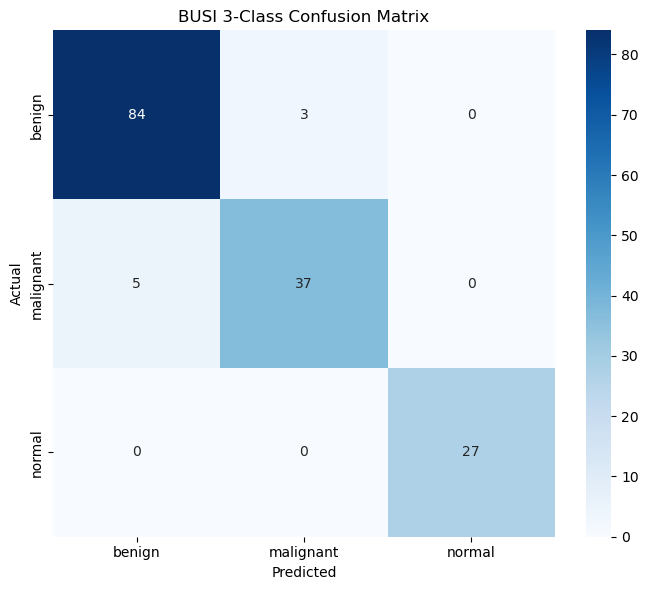


Saved model to: models/busi_3class_model.joblib
Saved confusion matrix image to: outputs/confusion_matrix.png


In [12]:
FEATURE_CSV = "outputs/busi_3class_features.csv"

def main():
    os.makedirs("models", exist_ok=True)
    os.makedirs("outputs", exist_ok=True)

    df = pd.read_csv(FEATURE_CSV)

    X = df.drop(columns=["image_path", "label"])
    y = df["label"]

    label_encoder = LabelEncoder()
    y_encoded = label_encoder.fit_transform(y)

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y_encoded,
        test_size=0.2,
        random_state=42,
        stratify=y_encoded
    )

    pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="constant", fill_value=0)),
        ("var_thresh", VarianceThreshold()),
        ("scaler", StandardScaler()),
        ("select", SelectKBest(score_func=f_classif, k=min(60, X.shape[1]))),
        ("clf", RandomForestClassifier(
            n_estimators=400,
            random_state=42,
            class_weight="balanced"
        ))
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    # =========================
    # METRICS
    # =========================
    acc = accuracy_score(y_test, y_pred)
    print(f"\nAccuracy: {acc:.4f}\n")

    print("Classification Report:\n")
    print(classification_report(
        y_test,
        y_pred,
        target_names=label_encoder.classes_
    ))

    # =========================
    # CONFUSION MATRIX (NUMERIC)
    # =========================
    cm = confusion_matrix(y_test, y_pred)

    print("\n==============================")
    print("CONFUSION MATRIX (RAW NUMERIC)")
    print("==============================")
    print(cm)

    # =========================
    # LABELED CONFUSION MATRIX
    # =========================
    cm_df = pd.DataFrame(
        cm,
        index=[f"Actual_{cls}" for cls in label_encoder.classes_],
        columns=[f"Predicted_{cls}" for cls in label_encoder.classes_]
    )

    print("\n=====================================")
    print("CONFUSION MATRIX (LABELED TABLE)")
    print("=====================================")
    print(cm_df)

    # save numeric matrix to CSV (so you can send it)
    cm_df.to_csv("outputs/confusion_matrix_numerical.csv")
    print("\nSaved numeric confusion matrix to:")
    print("outputs/confusion_matrix_numerical.csv")

    # =========================
    # HEATMAP VISUALIZATION
    # =========================
    plt.figure(figsize=(7, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=label_encoder.classes_,
        yticklabels=label_encoder.classes_
    )
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("BUSI 3-Class Confusion Matrix")
    plt.tight_layout()
    plt.savefig("outputs/confusion_matrix.png", dpi=300)
    plt.show()

    # =========================
    # SAVE MODEL
    # =========================
    bundle = {
        "model": pipeline,
        "label_encoder": label_encoder,
        "feature_columns": list(X.columns)
    }

    joblib.dump(bundle, "models/busi_3class_model.joblib")
    print("\nSaved model to: models/busi_3class_model.joblib")
    print("Saved confusion matrix image to: outputs/confusion_matrix.png")


if __name__ == "__main__":
    main()

### single-image prediction code

In [13]:
import joblib
import cv2
import numpy as np
import pandas as pd
from pathlib import Path
import re
from scipy.stats import skew, kurtosis, entropy
from skimage.feature import graycomatrix, graycoprops, local_binary_pattern
from skimage.measure import label, regionprops
import SimpleITK as sitk
from radiomics import featureextractor

In [14]:
MODEL_PATH = "models/busi_3class_model.joblib"

def load_gray_image(path):
    img = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError(f"Could not read image: {path}")
    return img

def normalize_image(img):
    return cv2.equalizeHist(img)

def merge_masks(mask_paths, shape=None):
    if not mask_paths:
        if shape is not None:
            return np.zeros(shape, dtype=np.uint8)
        return None

    merged = None
    for mp in mask_paths:
        mask = cv2.imread(str(mp), cv2.IMREAD_GRAYSCALE)
        if mask is None:
            continue
        mask = (mask > 0).astype(np.uint8)
        merged = mask if merged is None else np.maximum(merged, mask)

    if merged is None and shape is not None:
        return np.zeros(shape, dtype=np.uint8)

    return merged

def extract_global_features(img):
    flat = img.flatten().astype(np.float32)
    hist, _ = np.histogram(flat, bins=256, range=(0, 256), density=True)
    hist = hist + 1e-12
    edges = cv2.Canny(img, 50, 150)

    glcm = graycomatrix(img, distances=[1], angles=[0], levels=256, symmetric=True, normed=True)

    features = {
        "img_mean": float(np.mean(flat)),
        "img_std": float(np.std(flat)),
        "img_min": float(np.min(flat)),
        "img_max": float(np.max(flat)),
        "img_median": float(np.median(flat)),
        "img_skewness": float(skew(flat)),
        "img_kurtosis": float(kurtosis(flat)),
        "img_entropy": float(entropy(hist)),
        "img_edge_density": float(np.mean(edges > 0)),
        "img_glcm_contrast": float(graycoprops(glcm, "contrast")[0, 0]),
        "img_glcm_dissimilarity": float(graycoprops(glcm, "dissimilarity")[0, 0]),
        "img_glcm_homogeneity": float(graycoprops(glcm, "homogeneity")[0, 0]),
        "img_glcm_energy": float(graycoprops(glcm, "energy")[0, 0]),
        "img_glcm_correlation": float(graycoprops(glcm, "correlation")[0, 0]),
        "img_glcm_asm": float(graycoprops(glcm, "ASM")[0, 0]),
    }

    radius = 1
    n_points = 8 * radius
    lbp = local_binary_pattern(img, n_points, radius, method="uniform")
    lbp_hist, _ = np.histogram(
        lbp.ravel(),
        bins=np.arange(0, n_points + 3),
        range=(0, n_points + 2),
        density=True
    )

    for i, val in enumerate(lbp_hist):
        features[f"img_lbp_{i}"] = float(val)

    return features

def extract_roi_shape_features(mask):
    zero_features = {
        "roi_area": 0.0,
        "roi_perimeter": 0.0,
        "roi_circularity": 0.0,
        "roi_eccentricity": 0.0,
        "roi_solidity": 0.0,
        "roi_extent": 0.0,
        "roi_major_axis_length": 0.0,
        "roi_minor_axis_length": 0.0,
        "roi_aspect_ratio": 0.0,
    }

    if mask is None or np.sum(mask) == 0:
        return zero_features

    labeled = label(mask)
    props = regionprops(labeled)
    if len(props) == 0:
        return zero_features

    prop = max(props, key=lambda x: x.area)
    area = float(prop.area)
    perimeter = float(prop.perimeter) if prop.perimeter > 0 else 0.0
    circularity = (4 * np.pi * area / (perimeter ** 2)) if perimeter > 0 else 0.0

    major_axis = float(getattr(prop, "major_axis_length", 0.0))
    minor_axis = float(getattr(prop, "minor_axis_length", 0.0))
    aspect_ratio = (major_axis / minor_axis) if minor_axis > 0 else 0.0

    return {
        "roi_area": area,
        "roi_perimeter": perimeter,
        "roi_circularity": float(circularity),
        "roi_eccentricity": float(getattr(prop, "eccentricity", 0.0)),
        "roi_solidity": float(getattr(prop, "solidity", 0.0)),
        "roi_extent": float(getattr(prop, "extent", 0.0)),
        "roi_major_axis_length": major_axis,
        "roi_minor_axis_length": minor_axis,
        "roi_aspect_ratio": float(aspect_ratio),
    }

def extract_roi_intensity_features(img, mask):
    zero_features = {
        "roi_mean": 0.0,
        "roi_std": 0.0,
        "roi_min": 0.0,
        "roi_max": 0.0,
        "roi_median": 0.0,
        "roi_skewness": 0.0,
        "roi_kurtosis": 0.0,
    }

    if mask is None or np.sum(mask) == 0:
        return zero_features

    pixels = img[mask > 0].astype(np.float32)
    if len(pixels) == 0:
        return zero_features

    return {
        "roi_mean": float(np.mean(pixels)),
        "roi_std": float(np.std(pixels)),
        "roi_min": float(np.min(pixels)),
        "roi_max": float(np.max(pixels)),
        "roi_median": float(np.median(pixels)),
        "roi_skewness": float(skew(pixels)) if len(pixels) > 2 else 0.0,
        "roi_kurtosis": float(kurtosis(pixels)) if len(pixels) > 3 else 0.0,
    }

def build_radiomics_extractor():
    extractor = featureextractor.RadiomicsFeatureExtractor()
    extractor.settings["binWidth"] = 25
    extractor.settings["force2D"] = True
    extractor.settings["force2Ddimension"] = 0
    extractor.settings["normalize"] = True
    extractor.settings["normalizeScale"] = 100

    extractor.enableImageTypeByName("Original")
    extractor.enableFeatureClassByName("firstorder")
    extractor.enableFeatureClassByName("shape2D")
    extractor.enableFeatureClassByName("glcm")
    extractor.enableFeatureClassByName("glrlm")
    extractor.enableFeatureClassByName("glszm")
    extractor.enableFeatureClassByName("gldm")
    extractor.enableFeatureClassByName("ngtdm")
    return extractor

def extract_radiomics(img, mask, extractor):
    if mask is None or np.sum(mask) == 0:
        return {}

    img_sitk = sitk.GetImageFromArray(img.astype(np.float32))
    mask_sitk = sitk.GetImageFromArray(mask.astype(np.uint8))
    result = extractor.execute(img_sitk, mask_sitk)

    features = {}
    for k, v in result.items():
        if k.startswith("original_"):
            try:
                features[k] = float(v)
            except Exception:
                pass
    return features

def predict_case(image_path, mask_paths=None, is_normal_case=False):
    bundle = joblib.load(MODEL_PATH)
    model = bundle["model"]
    label_encoder = bundle["label_encoder"]
    feature_columns = bundle["feature_columns"]

    img = load_gray_image(image_path)
    img = normalize_image(img)

    record = {}

    if is_normal_case:
        mask = np.zeros(img.shape, dtype=np.uint8)
        record["has_lesion"] = 0
    else:
        mask = merge_masks(mask_paths, shape=img.shape)
        record["has_lesion"] = 1 if mask is not None and np.sum(mask) > 0 else 0

    record.update(extract_global_features(img))
    record.update(extract_roi_shape_features(mask))
    record.update(extract_roi_intensity_features(img, mask))

    extractor = build_radiomics_extractor()
    record.update(extract_radiomics(img, mask, extractor))

    x = pd.DataFrame([record])
    x = x.reindex(columns=feature_columns, fill_value=0.0)

    pred_idx = model.predict(x)[0]
    probs = model.predict_proba(x)[0]

    predicted_label = label_encoder.inverse_transform([pred_idx])[0]
    prob_dict = {
        cls: float(prob)
        for cls, prob in zip(label_encoder.classes_, probs)
    }

    return predicted_label, prob_dict

if __name__ == "__main__":
    # Example 1: abnormal image with mask
    image_path = r"C:\Users\HP PC\Downloads\archive (6)\Dataset_BUSI_with_GT\benign\benign (1).png"
    mask_paths = [r"C:\Users\HP PC\Downloads\archive (6)\Dataset_BUSI_with_GT\benign\benign (1)_mask.png"]

    pred, probs = predict_case(image_path, mask_paths=mask_paths, is_normal_case=False)
    print("Prediction:", pred)
    print("Probabilities:", probs)

    # Example 2: normal image
    # image_path = r"C:\Users\HP PC\Downloads\archive (6)\Dataset_BUSI_with_GT\normal\normal (1).png"
    # pred, probs = predict_case(image_path, mask_paths=None, is_normal_case=True)
    # print("Prediction:", pred)
    # print("Probabilities:", probs)

Shape features are only available 3D input (for 2D input, use shape2D). Found 2D input
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated


Prediction: benign
Probabilities: {'benign': 0.9125, 'malignant': 0.0875, 'normal': 0.0}


### LET US TRAIN WITH A NON-TREE MODEL SVM (support vector machine)

###  TRAIN


Accuracy: 0.8974

Classification Report:

              precision    recall  f1-score   support

      benign       0.95      0.86      0.90        87
   malignant       0.76      0.90      0.83        42
      normal       1.00      1.00      1.00        27

    accuracy                           0.90       156
   macro avg       0.90      0.92      0.91       156
weighted avg       0.91      0.90      0.90       156


CONFUSION MATRIX (RAW)
[[75 12  0]
 [ 4 38  0]
 [ 0  0 27]]

CONFUSION MATRIX (LABELED):
                  Predicted_benign  Predicted_malignant  Predicted_normal
Actual_benign                   75                   12                 0
Actual_malignant                 4                   38                 0
Actual_normal                    0                    0                27


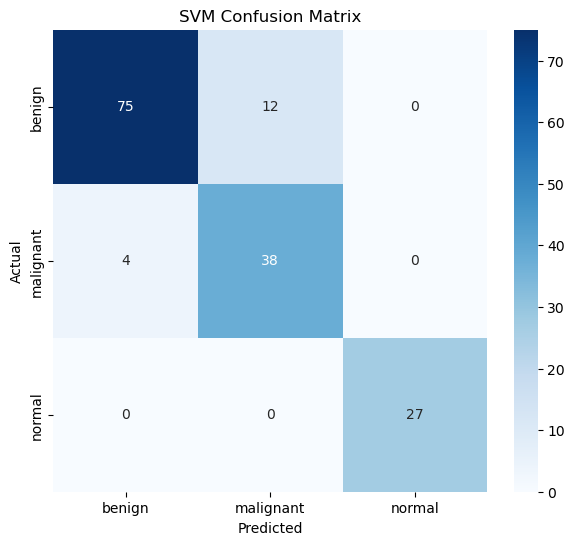


Model saved successfully ✅


In [15]:
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

FEATURE_CSV = "outputs/busi_3class_features.csv"

# =========================
# LOAD DATA
# =========================
df = pd.read_csv(FEATURE_CSV)

X = df.drop(columns=["image_path", "label"])
y = df["label"]

# =========================
# ENCODE LABELS
# =========================
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# =========================
# SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

# =========================
# PIPELINE
# =========================
k_best = min(60, X.shape[1])

pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value=0)),
    ("var_thresh", VarianceThreshold()),
    ("scaler", StandardScaler()),
    ("select", SelectKBest(score_func=f_classif, k=k_best)),
    ("clf", SVC(
        kernel="rbf",
        C=2.0,
        gamma="scale",
        class_weight="balanced",
        probability=True,
        random_state=42
    ))
])

# =========================
# TRAIN
# =========================
pipeline.fit(X_train, y_train)

# =========================
# PREDICT
# =========================
y_pred = pipeline.predict(X_test)

# =========================
# EVALUATE
# =========================
acc = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {acc:.4f}\n")

print("Classification Report:\n")
print(classification_report(
    y_test,
    y_pred,
    target_names=label_encoder.classes_
))

# =========================
# CONFUSION MATRIX
# =========================
cm = confusion_matrix(y_test, y_pred)

print("\n==============================")
print("CONFUSION MATRIX (RAW)")
print("==============================")
print(cm)

cm_df = pd.DataFrame(
    cm,
    index=[f"Actual_{cls}" for cls in label_encoder.classes_],
    columns=[f"Predicted_{cls}" for cls in label_encoder.classes_]
)

print("\nCONFUSION MATRIX (LABELED):")
print(cm_df)

# =========================
# PLOT
# =========================
plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("SVM Confusion Matrix")
plt.show()

# =========================
# SAVE MODEL
# =========================
os.makedirs("models", exist_ok=True)

joblib.dump({
    "model": pipeline,
    "label_encoder": label_encoder,
    "feature_columns": list(X.columns)
}, "models/svm_model.joblib")

print("\nModel saved successfully ✅")

###  LET US APLLY LightGBM to TRAIN

C:\Users\HP PC\.conda\envs\radiomics\lib\site-packages\sklearn\feature_selection\_univariate_selection.py:112: RuntimeWarning: divide by zero encountered in divide
  f = msb / msw


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001159 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 13485
[LightGBM] [Info] Number of data points in the train set: 624, number of used features: 80
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

C:\Users\HP PC\.conda\envs\radiomics\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



Accuracy: 0.9744

Classification Report:

              precision    recall  f1-score   support

      benign       0.99      0.97      0.98        87
   malignant       0.93      0.98      0.95        42
      normal       1.00      1.00      1.00        27

    accuracy                           0.97       156
   macro avg       0.97      0.98      0.98       156
weighted avg       0.98      0.97      0.97       156


CONFUSION MATRIX (RAW)
[[84  3  0]
 [ 1 41  0]
 [ 0  0 27]]

CONFUSION MATRIX (LABELED TABLE)
                  Predicted_benign  Predicted_malignant  Predicted_normal
Actual_benign                   84                    3                 0
Actual_malignant                 1                   41                 0
Actual_normal                    0                    0                27

Saved numeric confusion matrix to:
outputs/confusion_matrix_lightgbm_numerical.csv


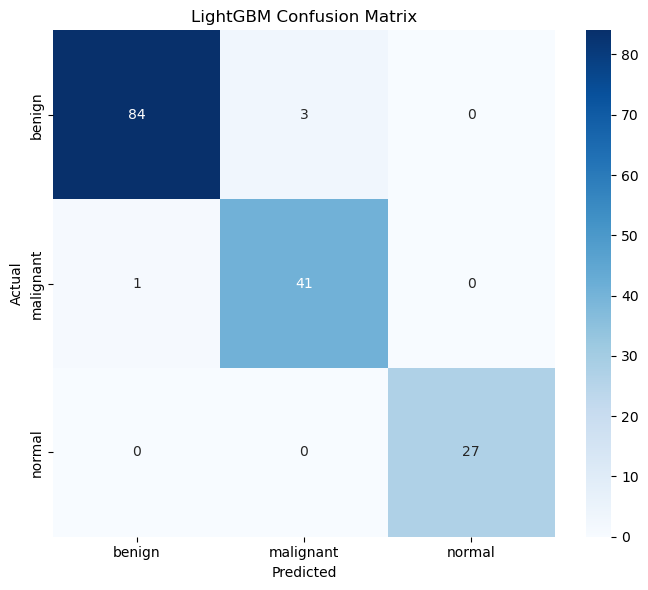


Model saved successfully: models/lightgbm_model.joblib
Confusion matrix image saved: outputs/confusion_matrix_lightgbm.png


In [16]:
import os
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from lightgbm import LGBMClassifier

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

FEATURE_CSV = "outputs/busi_3class_features.csv"

# =========================
# LOAD DATA
# =========================
df = pd.read_csv(FEATURE_CSV)

X = df.drop(columns=["image_path", "label"])
y = df["label"]

# =========================
# ENCODE LABELS
# =========================
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# =========================
# SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

# =========================
# FEATURE SELECTION SIZE
# =========================
k_best = min(80, X.shape[1])

# =========================
# PIPELINE
# =========================
pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value=0)),
    ("var_thresh", VarianceThreshold()),
    ("select", SelectKBest(score_func=f_classif, k=k_best)),
    ("clf", LGBMClassifier(
        objective="multiclass",
        num_class=len(label_encoder.classes_),
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        num_leaves=31,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_alpha=0.1,
        reg_lambda=0.1,
        random_state=42,
        class_weight="balanced"
    ))
])

# =========================
# TRAIN
# =========================
pipeline.fit(X_train, y_train)

# =========================
# PREDICT
# =========================
y_pred = pipeline.predict(X_test)

# =========================
# EVALUATE
# =========================
acc = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {acc:.4f}\n")

print("Classification Report:\n")
print(classification_report(
    y_test,
    y_pred,
    target_names=label_encoder.classes_
))

# =========================
# CONFUSION MATRIX
# =========================
cm = confusion_matrix(y_test, y_pred)

print("\n==============================")
print("CONFUSION MATRIX (RAW)")
print("==============================")
print(cm)

cm_df = pd.DataFrame(
    cm,
    index=[f"Actual_{cls}" for cls in label_encoder.classes_],
    columns=[f"Predicted_{cls}" for cls in label_encoder.classes_]
)

print("\n=====================================")
print("CONFUSION MATRIX (LABELED TABLE)")
print("=====================================")
print(cm_df)

# save numeric confusion matrix
os.makedirs("outputs", exist_ok=True)
cm_df.to_csv("outputs/confusion_matrix_lightgbm_numerical.csv")
print("\nSaved numeric confusion matrix to:")
print("outputs/confusion_matrix_lightgbm_numerical.csv")

# =========================
# PLOT
# =========================
plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("LightGBM Confusion Matrix")
plt.tight_layout()
plt.savefig("outputs/confusion_matrix_lightgbm.png", dpi=300)
plt.show()

# =========================
# SAVE MODEL
# =========================
os.makedirs("models", exist_ok=True)

joblib.dump({
    "model": pipeline,
    "label_encoder": label_encoder,
    "feature_columns": list(X.columns)
}, "models/lightgbm_model.joblib")

print("\nModel saved successfully: models/lightgbm_model.joblib")
print("Confusion matrix image saved: outputs/confusion_matrix_lightgbm.png")

### 🩺 Breast Cancer Classification Using Radiomics and Machine Learning

---

## 1. Introduction

Breast cancer is one of the leading causes of death among women worldwide. Early detection significantly improves treatment outcomes and survival rates. Ultrasound imaging is widely used due to its affordability, safety, and effectiveness in detecting breast lesions.

This project presents a machine learning-based approach for classifying breast ultrasound images into **benign, malignant, and normal classes** using advanced feature extraction and radiomics.

---

## 2. Objective

The main objectives of this project are:

- To classify breast ultrasound images into:
  - Benign
  - Malignant
  - Normal
- To extract meaningful features using:
  - Global image features
  - ROI shape features
  - ROI intensity features
  - Radiomics features
- To evaluate different machine learning models and identify the best-performing model

---

## 3. Dataset Description

The dataset used is the **BUSI (Breast Ultrasound Images) dataset**, structured as:

### - Benign and malignant classes include segmentation masks
### - Normal class contains only images



## 4. Feature Extraction Methodology

A hybrid feature extraction approach was used:

### 4.1 Global Image Features
- Mean intensity
- Standard deviation
- Minimum and maximum intensity
- Histogram-based statistics
- Entropy and texture features

---

### 4.2 ROI Shape Features
Extracted from lesion masks:

- Area
- Perimeter
- Circularity
- Eccentricity
- Solidity
- Aspect ratio

These help distinguish:
- Benign → smoother, regular shapes  
- Malignant → irregular, complex shapes  

---

### 4.3 ROI Intensity Features

- Mean intensity
- Standard deviation
- Median
- Minimum and maximum
- Distribution statistics

---

### 4.4 Radiomics Features

Using **PyRadiomics**, the following were extracted:

- First-order statistics
- Shape2D features
- Texture features:
  - GLCM
  - GLRLM
  - GLSZM
  - GLDM
  - NGTDM

---

### 4.5 Dataset Indexing

- Images and masks were matched correctly
- Multiple masks were merged when present
- For **normal images**:
  - ROI features = 0
  - Global features retained

---

### 4.6 Final Feature Representation

Each sample is represented as:

**Global Features + ROI Shape + ROI Intensity + Radiomics**

This significantly improves model performance.

---

## 5. Model Development

Three models were evaluated:

- Random Forest
- Support Vector Machine (SVM)
- LightGBM

---

## 6. Results and Evaluation

---

### 6.1 Random Forest

**Accuracy:** 94.87%

#### Classification Report

| Class      | Precision | Recall | F1-score | Support |
|------------|----------|--------|----------|---------|
| Benign     | 0.94     | 0.97   | 0.95     | 87      |
| Malignant  | 0.93     | 0.88   | 0.90     | 42      |
| Normal     | 1.00     | 1.00   | 1.00     | 27      |

#### Confusion Matrix

|                | Predicted Benign | Predicted Malignant | Predicted Normal |
|----------------|------------------|---------------------|------------------|
| Actual Benign  | 84               | 3                   | 0                |
| Actual Malignant| 5               | 37                  | 0                |
| Actual Normal  | 0                | 0                   | 27               |

---

### 6.2 Support Vector Machine (SVM)

**Accuracy:** 89.74%

#### Classification Report

| Class      | Precision | Recall | F1-score | Support |
|------------|----------|--------|----------|---------|
| Benign     | 0.95     | 0.86   | 0.90     | 87      |
| Malignant  | 0.76     | 0.90   | 0.83     | 42      |
| Normal     | 1.00     | 1.00   | 1.00     | 27      |

#### Confusion Matrix

|                | Predicted Benign | Predicted Malignant | Predicted Normal |
|----------------|------------------|---------------------|------------------|
| Actual Benign  | 75               | 12                  | 0                |
| Actual Malignant| 4               | 38                  | 0                |
| Actual Normal  | 0                | 0                   | 27               |

---

### 6.3 LightGBM (Best Model)

**Accuracy:** 97.44%

#### Classification Report

| Class      | Precision | Recall | F1-score | Support |
|------------|----------|--------|----------|---------|
| Benign     | 0.99     | 0.97   | 0.98     | 87      |
| Malignant  | 0.93     | 0.98   | 0.95     | 42      |
| Normal     | 1.00     | 1.00   | 1.00     | 27      |

#### Confusion Matrix

|                | Predicted Benign | Predicted Malignant | Predicted Normal |
|----------------|------------------|---------------------|------------------|
| Actual Benign  | 84               | 3                   | 0                |
| Actual Malignant| 1               | 41                  | 0                |
| Actual Normal  | 0                | 0                   | 27               |

---

## 7. Discussion

### Model Comparison

| Model          | Accuracy |
|---------------|--------|
| Random Forest | 94.87% |
| SVM           | 89.74% |
| LightGBM      | 97.44% |

---

### Key Observations

- Tree-based models outperform SVM
- LightGBM achieved the best performance
- Normal class achieved 100% accuracy
- Only 1 malignant case misclassified (very strong result)

---

## 8. System Implementation

The system includes:

- Feature extraction pipeline
- Machine learning model (LightGBM)
- Streamlit web application
- Optional FastAPI backend

---

## 9. Conclusion

This project demonstrates that:

- Radiomics + handcrafted features significantly improve classification
- LightGBM is highly effective for medical imaging tasks
- The system achieves:

  - 97.44% accuracy
  - High malignant detection (98% recall)
  - Perfect normal classification

---

## 10. Future Work

- Automatic lesion segmentation
- Deep learning integration (CNN)
- Clinical deployment
- Cross-dataset validation

---

## 11. Final Remark

This project presents a **robust, real-world applicable breast cancer classification system** combining:

- Radiomics
- Feature engineering
- Machine learning
